### Importa los datos
Dataset con diferentes fármacos, sus efectos y ratings de los clientes.

Importa el dataset *drugLibTrain_raw.tsv*

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Descriptive Analysis

Quedate únicamente con las columnas que podamos manejar: Columnas numéricas y columnas categóricas con pocas categorías (menos de 10)

In [4]:
df = pd.read_csv('data/drugLibTrain_raw.tsv', sep="\t", index_col=0)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3107 entries, 2202 to 2748
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   urlDrugName        3107 non-null   object
 1   rating             3107 non-null   int64 
 2   effectiveness      3107 non-null   object
 3   sideEffects        3107 non-null   object
 4   condition          3106 non-null   object
 5   benefitsReview     3089 non-null   object
 6   sideEffectsReview  3032 non-null   object
 7   commentsReview     3095 non-null   object
dtypes: int64(1), object(7)
memory usage: 218.5+ KB


In [6]:
# Genera estadísticas descriptivas completas del DataFrame.
# include="all" asegura que se incluyan tanto columnas numéricas (media, std, etc.) 
# como categóricas (count, unique, top, freq).
df.describe(include="all")


,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
count,3107,3107.000000,3107,3107,3106,3089,3032,3095
unique,502,NaN,5,5,1426,3031,2813,3046
top,lexapro,NaN,Highly Effective,Mild Side Effects,depression,none,none,none
freq,63,NaN,1330,1019,236,20,112,6
mean,NaN,7.006115,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,2.937582,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,8.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN


#### Transforma las columnas categóricas

Transforma las columnas categoricas a numericas mediante dummies

In [7]:
# Convierte la columna categórica 'effectiveness' en variables "dummy" o de indicadores.
# Crea una columna nueva por cada categoría única, marcando con 1 si el registro 
# pertenece a esa categoría y con 0 si no (One-Hot Encoding).
pd.get_dummies(df['effectiveness'])


,Considerably Effective,Highly Effective,Ineffective,Marginally Effective,Moderately Effective
2202,False,True,False,False,False
3117,False,True,False,False,False
1146,False,True,False,False,False
3947,False,False,False,True,False
1951,False,False,False,True,False
...,...,...,...,...,...
1039,False,True,False,False,False
3281,False,False,True,False,False
1664,False,False,False,True,False
2621,True,False,False,False,False


In [8]:
# Crea una copia profunda (deep copy) del DataFrame original 'df'.
# Esto permite realizar cambios en 'df2' sin afectar los datos originales de 'df', 
# asegurando que ambos objetos sean independientes en la memoria.
df2 = df.copy()


In [9]:
# Selecciona solo las columnas 'effectiveness', 'sideEffects' y 'rating' para trabajar.
df2 = df2[["effectiveness","sideEffects","rating"]]

# Aplica One-Hot Encoding a todas las columnas seleccionadas, convirtiendo
# las categorías de texto en columnas numéricas de 0 y 1.
df2 = pd.get_dummies(df2[["effectiveness","sideEffects","rating"]])

# Importa las herramientas para normalizar (MinMaxScaler) y estandarizar (StandardScaler) los datos.
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Inicializa el escalador estándar (resta la media y divide por la desviación estándar).
scaler = StandardScaler()

# Ajusta el escalador con los datos de df2 y los transforma, centrando los valores en 0
# y dándoles una varianza unitaria. El resultado 'datos_scal' es un array de NumPy.
datos_scal = scaler.fit_transform(df2)


In [10]:
# Obtiene una lista (o array) con todos los valores únicos presentes 
# en la columna 'effectiveness', eliminando los duplicados.
# Útil para conocer las categorías existentes antes de transformarlas.
df['effectiveness'].unique()


array(['Highly Effective', 'Marginally Effective', 'Ineffective',
       'Considerably Effective', 'Moderately Effective'], dtype=object)

In [11]:
# Define un diccionario de mapeo para convertir categorías textuales en valores numéricos ordinales.
my_effectiveness = {
    "Ineffective": 0,
    "Marginally Effective": 1,
    "Moderately Effective": 2,
    "Considerably Effective": 3,
    "Highly Effective": 4
}

# Crea una nueva columna 'effectiveness_int' aplicando el mapeo a la columna original.
# Esto transforma el texto en una escala numérica del 0 al 4.
df['effectiveness_int'] = df['effectiveness'].map(my_effectiveness)

# Muestra las primeras 5 filas del DataFrame para verificar que la nueva columna se añadió correctamente.
df.head()


,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview,effectiveness_int
2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ...",4
3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest...",4
1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...,4
3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...,1
1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above,1


In [12]:
# Recupera todos los valores distintos que existen en la columna 'sideEffects'.
# Esto te permite identificar las categorías de efectos secundarios para 
# decidir si aplicarás un mapeo ordinal (como en el paso anterior) o One-Hot Encoding.
df['sideEffects'].unique()


array(['Mild Side Effects', 'Severe Side Effects', 'No Side Effects',
       'Extremely Severe Side Effects', 'Moderate Side Effects'],
      dtype=object)

In [13]:
# Define un diccionario para transformar la intensidad de los efectos secundarios 
# en una escala numérica ordenada (de 0 a 4).
my_sideEffects = {
    "No Side Effects": 0,
    "Mild Side Effects": 1,
    "Moderate Side Effects": 2,
    "Severe Side Effects": 3,
    "Extremely Severe Side Effects": 4
}

# Crea la columna 'sideEffects_int' traduciendo las etiquetas de texto a números.
df['sideEffects_int'] = df['sideEffects'].map(my_sideEffects)

# Visualiza el inicio del DataFrame para confirmar el mapeo de ambas variables.
df.head()


,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview,effectiveness_int,sideEffects_int
2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ...",4,1
3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest...",4,3
1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...,4,0
3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...,1,1
1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above,1,3


In [14]:
# Crea la matriz de características 'X' seleccionando las variables numéricas:
# la puntuación ('rating') y las versiones codificadas de efectividad y efectos secundarios.
X = df[['rating', "effectiveness_int", "sideEffects_int"]]

# Imprime las dimensiones del conjunto resultante (número de filas, número de columnas).
# Sirve para confirmar que los datos se han filtrado correctamente antes de entrenar un modelo.
print(X.shape)


(3107, 3)


In [15]:
# Genera un resumen estadístico de las columnas seleccionadas en 'X'.
# Muestra métricas clave como el conteo de datos, la media, la desviación estándar,
# los valores mínimo y máximo, y los percentiles (25%, 50%, 75%).
X.describe()


,rating,effectiveness_int,sideEffects_int
count,3107.000000,3107.000000,3107.000000
mean,7.006115,2.935629,1.304796
std,2.937582,1.230531,1.177482
min,1.000000,0.000000,0.000000
25%,5.000000,2.000000,0.000000
50%,8.000000,3.000000,1.000000
75%,9.000000,4.000000,2.000000
max,10.000000,4.000000,4.000000


#### Evalua cual es la mejor K

Utiliza silhouette_score para evaluar cual es la mejor K.

#### Genera el K Means 

In [16]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [17]:
# Crea una lista de modelos KMeans entrenados. 
# Itera (k) de 2 a 29 clusters para evaluar cuál es el número óptimo.
# n_init=10: Ejecuta el algoritmo 10 veces con diferentes semillas para evitar mínimos locales.
# random_state=10: Asegura que los resultados sean reproducibles.
km_list = [KMeans(n_clusters=k, n_init=10, random_state=10).fit(X) for k in range(2,30)]

# Muestra la lista con los 28 objetos KMeans ya ajustados a los datos de X.
km_list


[KMeans(n_clusters=2, n_init=10, random_state=10),
 KMeans(n_clusters=3, n_init=10, random_state=10),
 KMeans(n_clusters=4, n_init=10, random_state=10),
 KMeans(n_clusters=5, n_init=10, random_state=10),
 KMeans(n_clusters=6, n_init=10, random_state=10),
 KMeans(n_clusters=7, n_init=10, random_state=10),
 KMeans(n_init=10, random_state=10),
 KMeans(n_clusters=9, n_init=10, random_state=10),
 KMeans(n_clusters=10, n_init=10, random_state=10),
 KMeans(n_clusters=11, n_init=10, random_state=10),
 KMeans(n_clusters=12, n_init=10, random_state=10),
 KMeans(n_clusters=13, n_init=10, random_state=10),
 KMeans(n_clusters=14, n_init=10, random_state=10),
 KMeans(n_clusters=15, n_init=10, random_state=10),
 KMeans(n_clusters=16, n_init=10, random_state=10),
 KMeans(n_clusters=17, n_init=10, random_state=10),
 KMeans(n_clusters=18, n_init=10, random_state=10),
 KMeans(n_clusters=19, n_init=10, random_state=10),
 KMeans(n_clusters=20, n_init=10, random_state=10),
 KMeans(n_clusters=21, n_init=10, 

In [18]:
# Calcula el coeficiente de silueta para cada uno de los modelos entrenados.
# 'model.labels_' extrae las etiquetas de los clusters asignados a cada fila.
# El resultado es una lista que mide qué tan bien separado está cada cluster (de -1 a 1).
silhouette_score_list = [silhouette_score(X, model.labels_) for model in km_list]

# Muestra la lista de puntuaciones obtenidas para cada valor de 'k'.
silhouette_score_list


[0.6190969508782411,
 0.4541665291694327,
 0.416701237123931,
 0.4152173517501398,
 0.4023764724520682,
 0.40557580829247497,
 0.3867321491862528,
 0.4031908327501373,
 0.40546081621775343,
 0.418564395282399,
 0.4209951052127568,
 0.42472767802639305,
 0.44422026666347153,
 0.45321061939472584,
 0.4753626098033833,
 0.5238076296330578,
 0.5109596642665494,
 0.4859662106692393,
 0.5228878403066904,
 0.531607509306112,
 0.5315322660374614,
 0.5457629738673985,
 0.5450085706358424,
 0.5907873581539258,
 0.5997424227195615,
 0.6002131744283817,
 0.5975645913474263,
 0.605096781106952]

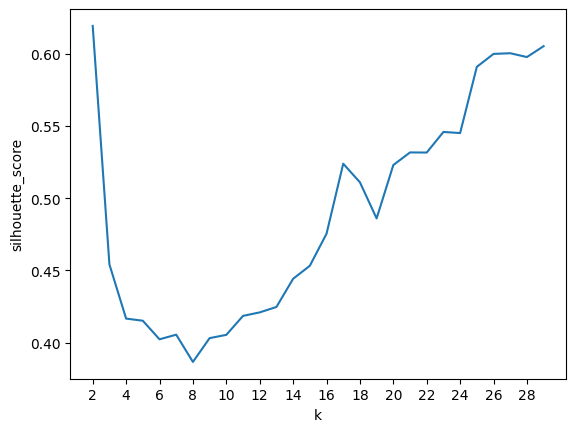

In [19]:
# Dibuja un gráfico de líneas relacionando el número de clusters (k) con su puntuación de silueta.
plt.plot(range(2,30), silhouette_score_list)

# Etiqueta el eje X como 'k' (número de grupos).
plt.xlabel("k")

# Etiqueta el eje Y como 'silhouette_score' (calidad de la agrupación).
plt.ylabel("silhouette_score")

# Configura las marcas del eje X para que vayan de 2 en 2, facilitando la lectura.
plt.xticks(range(2,30,2));


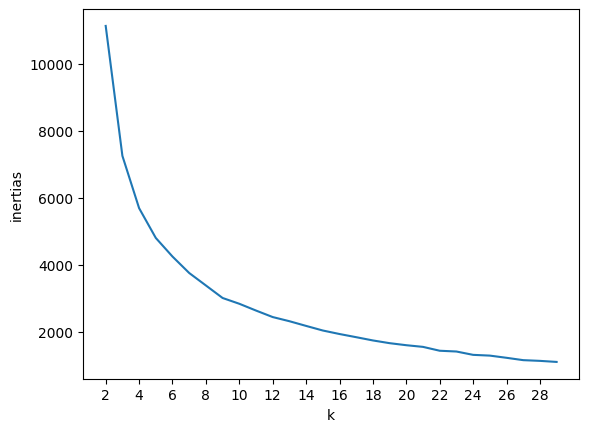

In [20]:
# Extrae la inercia (suma de cuadrados de las distancias dentro de los clusters) 
# de cada modelo entrenado para aplicar el "método del codo" (Elbow Method).
inertias = [model.inertia_ for model in km_list]

# Grafica la evolución de la inercia según aumenta el número de clusters (k).
plt.plot(range(2,30), inertias)

# Define las etiquetas de los ejes X e Y para identificar k e inercia.
plt.xlabel("k")
plt.ylabel("inertias")

# Ajusta el eje X con intervalos de 2 para localizar mejor el "punto de inflexión".
plt.xticks(range(2,30,2));


Comprueba los resultados y muestra en un pie plot la distribución de los distintos clusters.

In [21]:
# Entrena el modelo final de KMeans configurado con 2 clusters.
# Se mantienen n_init=10 y random_state=10 para asegurar consistencia con las pruebas previas.
kmeans = KMeans(n_clusters=2, n_init=10, random_state=10).fit(X)

# Extrae las etiquetas (0 o 1) asignadas a cada fila de los datos originales.
# Esto indica a qué grupo pertenece cada registro según el modelo.
kmeans.labels_


array([0, 0, 1, ..., 0, 1, 0], shape=(3107,), dtype=int32)

In [22]:
# Crea una copia del conjunto de características X para evitar modificar los datos originales.
df_cluster = X.copy()

# Añade una nueva columna llamada 'cluster' con las etiquetas asignadas por el modelo KMeans.
# Esto permite identificar a qué grupo pertenece cada fila (medicamento/paciente).
df_cluster['cluster'] = kmeans.labels_

# Muestra el DataFrame resultante con las variables originales y su cluster correspondiente.
df_cluster


,rating,effectiveness_int,sideEffects_int,cluster
2202,4,4,1,0
3117,1,4,3,0
1146,10,4,0,1
3947,3,1,1,0
1951,2,1,3,0
...,...,...,...,...
1039,10,4,1,1
3281,1,0,4,0
1664,2,1,2,0
2621,8,3,1,1


In [23]:
# Cuenta cuántos registros han sido asignados a cada cluster.
# Útil para verificar si los grupos están equilibrados o si uno es 
# significativamente más grande que el otro.
df_cluster['cluster'].value_counts()


cluster
1    2284
0     823
Name: count, dtype: int64

In [24]:
# Agrupa los datos según el número de cluster asignado y genera 
# estadísticas descriptivas detalladas para cada grupo.
# Esto permite comparar la media, desviación estándar, mínimos y máximos 
# de 'rating', 'effectiveness_int' y 'sideEffects_int' entre los clusters.
df_cluster.groupby("cluster").describe()


rating                                                 \
          count      mean       std  min  25%  50%   75%   max   
cluster                                                          
0         823.0  2.667072  1.570244  1.0  1.0  3.0   4.0   6.0   
1        2284.0  8.569615  1.272701  5.0  8.0  9.0  10.0  10.0   

        effectiveness_int            ...           sideEffects_int            \
                    count      mean  ...  75%  max           count      mean   
cluster                              ...                                       
0                   823.0  1.584447  ...  3.0  4.0           823.0  2.482382   
1                  2284.0  3.422504  ...  4.0  4.0          2284.0  0.880473   

                                            
              std  min  25%  50%  75%  max  
cluster                                     
0        1.182545  0.0  2.0  3.0  3.0  4.0  
1        0.838299  0.0  0.0  1.0  1.0  4.0  

[2 rows x 24 columns]

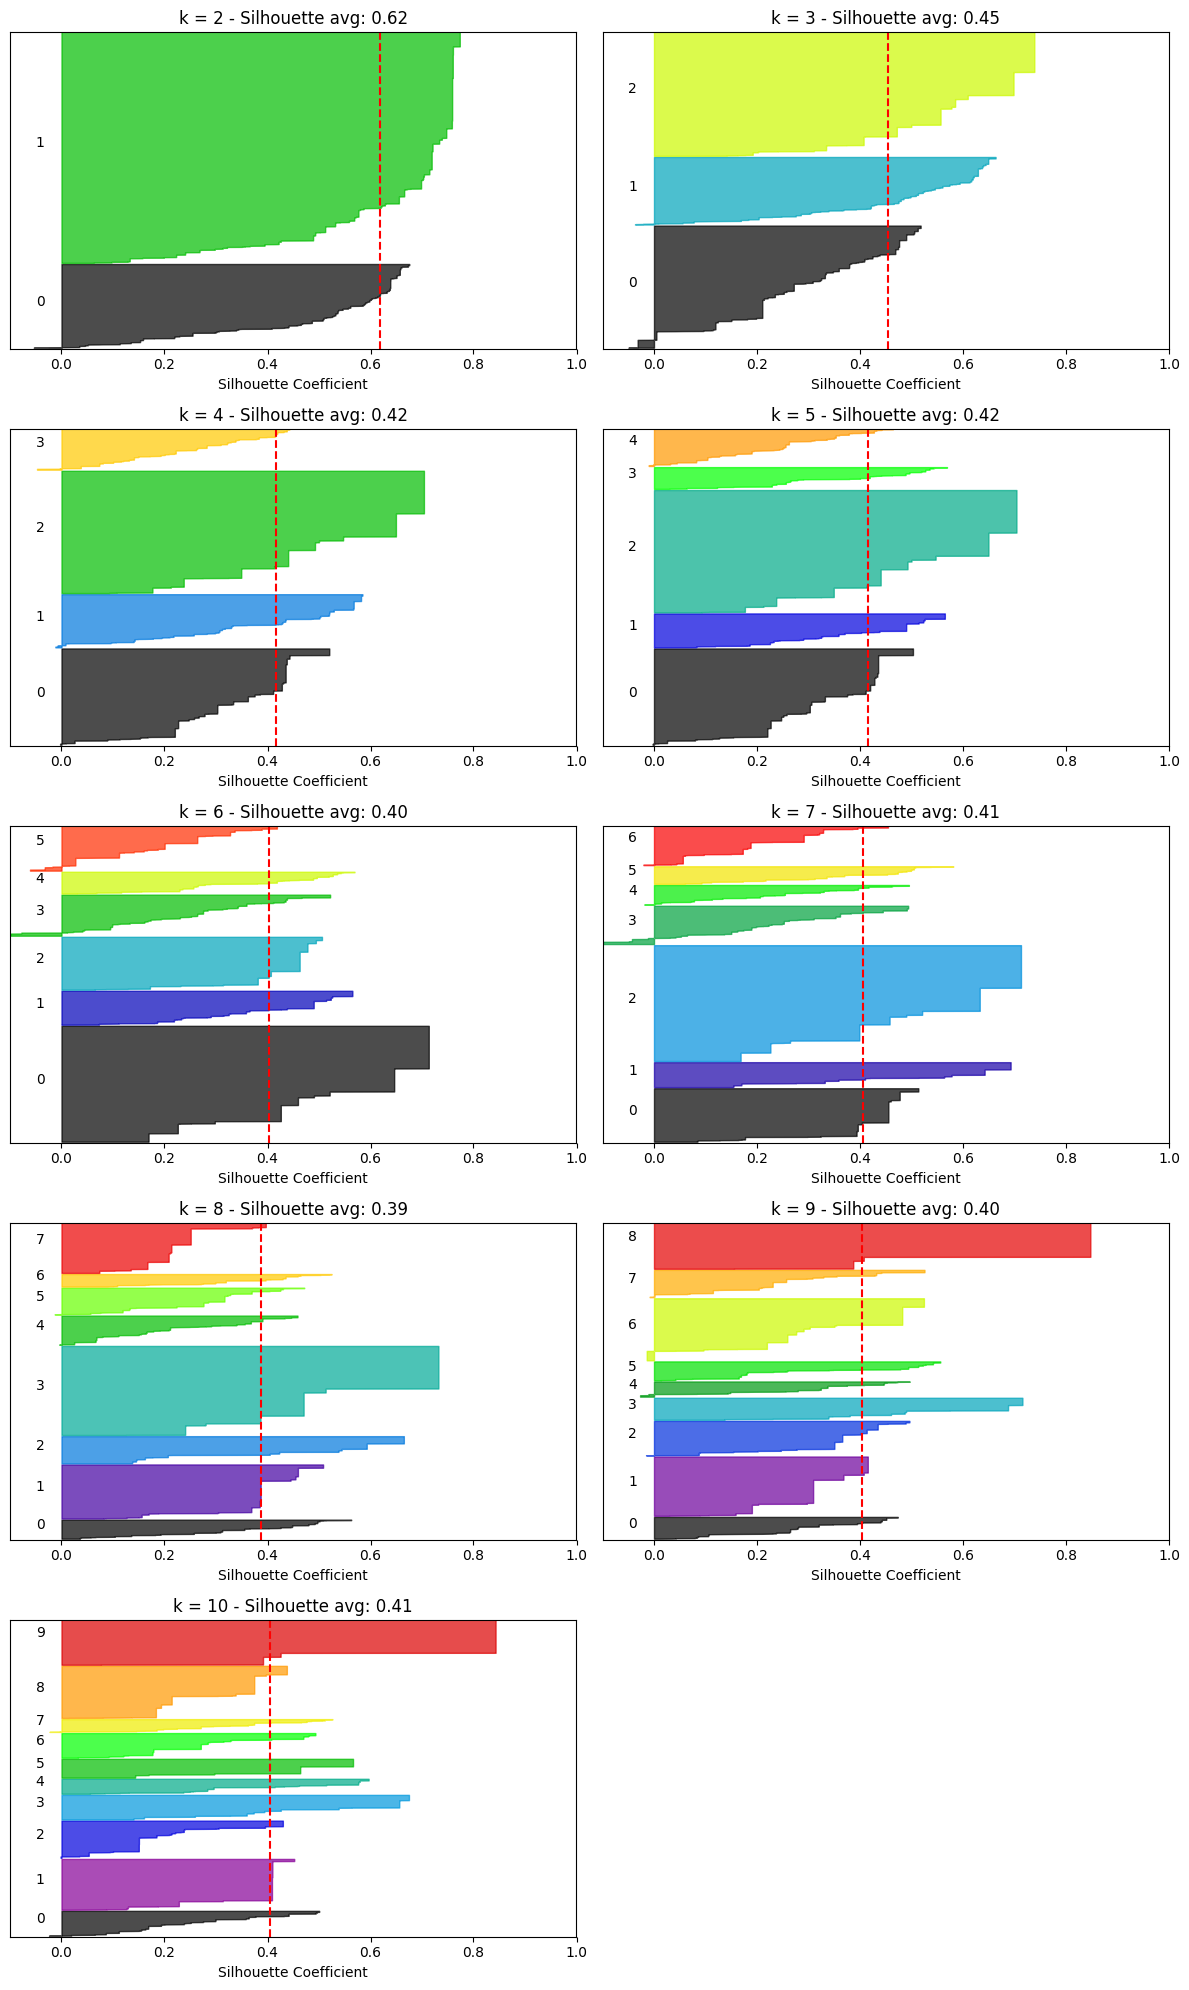

In [25]:
# Importa las librerías necesarias para visualización (matplotlib) y 
# cálculo de métricas de calidad de clustering (silhouette).
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples, silhouette_score
import numpy as np

# Configura una cuadrícula de gráficos de 5 filas por 2 columnas para mostrar los resultados de k=2 a k=10.
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 20))
axes = axes.flatten() # Aplana la matriz de ejes para iterar fácilmente sobre ellos.

# Itera sobre el rango de clusters evaluados (del 2 al 10).
for i, k in enumerate(range(2, 11)):
    ax = axes[i]
    kmeans = km_list[i]  # Recupera el modelo ya entrenado de la lista creada anteriormente.
    labels = kmeans.labels_
    
    # Calcula el coeficiente de silueta individual para cada muestra y el promedio general.
    silhouette_vals = silhouette_samples(X, labels)
    silhouette_avg = silhouette_score(X, labels)
    y_lower = 10 # Espacio inicial en el eje Y para el primer bloque del gráfico.

    # Dibuja la silueta para cada cluster individual dentro del gráfico actual.
    for cluster in range(k):
        # Filtra y ordena los valores de silueta de las muestras que pertenecen al cluster actual.
        cluster_sil_vals = silhouette_vals[labels == cluster]
        cluster_sil_vals.sort()
        size = len(cluster_sil_vals)
        y_upper = y_lower + size
        
        # Asigna un color específico al cluster usando una paleta espectral.
        color = cm.nipy_spectral(float(cluster) / k)
        
        # Rellena el área horizontal que representa la calidad de las muestras en este cluster.
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil_vals,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size, str(cluster)) # Indica el número de cluster.
        y_lower = y_upper + 10  # Deja un espacio de 10 unidades antes de dibujar el siguiente cluster.

    # Dibuja una línea roja punteada que marca el promedio de silueta de todo el modelo.
    ax.axvline(silhouette_avg, color="red", linestyle="--")
    ax.set_title(f'k = {k} - Silhouette avg: {silhouette_avg:.2f}')
    ax.set_xlim([-0.1, 1]) # Rango estándar del coeficiente de silueta.
    ax.set_ylim([0, len(X)]) # El eje Y representa el total de muestras.
    ax.set_yticks([]) # Oculta los valores numéricos del eje Y para limpiar la vista.
    ax.set_xlabel("Silhouette Coefficient")

# Si sobran subplots en la cuadrícula (porque 9 gráficos no llenan los 10 espacios), elimina el último.
if len(axes) > 9:
    fig.delaxes(axes[-1])

plt.tight_layout() # Ajusta automáticamente los márgenes para que no se solapen los títulos.
plt.show() # Muestra el panel completo de gráficos de silueta.


In [26]:
# Entrena un nuevo modelo KMeans, esta vez configurado para encontrar 4 clusters.
# Mantiene n_init=10 y random_state=10 para asegurar que los resultados sean estables.
kmeans = KMeans(n_clusters=4, n_init=10, random_state=10).fit(X)

# Extrae las etiquetas asignadas (0, 1, 2 o 3) a cada fila del conjunto X.
# Estas etiquetas clasifican cada registro en uno de los 4 grupos identificados.
kmeans.labels_


array([3, 1, 2, ..., 1, 0, 3], shape=(3107,), dtype=int32)

In [27]:
# Crea una copia de seguridad de las características 'X' para no alterar los datos originales.
df_cluster = X.copy()

# Asigna las nuevas etiquetas de los 4 clusters (0, 1, 2, 3) a una columna llamada 'cluster'.
# Esto vincula cada registro con su grupo correspondiente tras el entrenamiento del modelo.
df_cluster['cluster'] = kmeans.labels_

# Muestra el DataFrame final para inspeccionar cómo han quedado clasificados los datos.
df_cluster


,rating,effectiveness_int,sideEffects_int,cluster
2202,4,4,1,3
3117,1,4,3,1
1146,10,4,0,2
3947,3,1,1,1
1951,2,1,3,1
...,...,...,...,...
1039,10,4,1,2
3281,1,0,4,1
1664,2,1,2,1
2621,8,3,1,0
